# Final Model Comparison

Walk-forward CV (2020-2024) **and** 2025 out-of-sample for all candidate models.

| Model | Description |
|---|---|
| `elo` | Raw Elo probability (baseline) |
| `xgb` | XGBoost, 160 features, base_margin=logit(p_elo), tuning3 rank-2 params |
| `xgb_platt` | XGBoost + Platt calibration (a=-0.0431, b=0.9751) |
| `xgbpure` | XGBoost, 162 features (160+home/away elo_pre), no base_margin |
| `logit_160` | L2 logistic regression, 160 features, logit(p_elo) offset |
| `logit_162` | Same + home_elo_pre / away_elo_pre |
| `ensemble` | 20 bootstrap XGBoost models, mean prediction + std/min/max |

CV protocol: early-stop on Y-1, retrain on 2015..Y-1, test on Y. Cold-start rows removed.

In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import xgboost as xgb
from scipy.optimize import minimize
from scipy.special import expit
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path('../..').resolve()
GOLD_DIR = PROJECT_ROOT / 'data' / 'gold' / 'stage1' / 'hM7_Linj14_tau150_hT7'
OUT_DIR  = PROJECT_ROOT / 'data' / 'final_comparisons'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Tuning3 rank-2 winner (rank-1 had min_best_round=2 instability)
XGB_PARAMS = dict(
    objective='binary:logistic', eval_metric='logloss',
    max_depth=6, min_child_weight=3, subsample=0.8,
    colsample_bytree=0.6, reg_lambda=1.0, reg_alpha=0.0,
    gamma=0.1, learning_rate=0.02, seed=42, nthread=-1,
)
# Platt params from calibration.ipynb (pooled OOF 2020-2024)
PLATT_A, PLATT_B = -0.043139, 0.975050

N_PLAYERS  = 7
EARLY_STOP = 150
MAX_ROUNDS = 3000
N_ENS      = 20
ENS_SEED   = 42
CV_YEARS   = list(range(2020, 2025))
LABEL_COL  = 'home_win'
ELO_COL    = 'p_elo'
CLIP_EPS   = 1e-7
ALPHA_GRID = [1e-4, 1e-3, 1e-2, 0.1, 1.0, 10.0, 100.0]

PLAYER_FEATS = ['m_ewma_pre','q_pre','days_since_first_report_pre','days_since_last_dnp_pre',
                'consec_dnps_pre','played_last_game_pre','minutes_last_game_pre',
                'days_since_last_played_pre','injury_present_flag_pre']
FORM_FEATS   = ['net_rtg_ewma_pre','efg_ewma_pre','tov_pct_ewma_pre','orb_pct_ewma_pre','ftr_ewma_pre']
STYLE_FEATS  = ['off_3pa_rate_pre','def_3pa_allowed_pre','off_2pa_rate_pre','def_2pa_allowed_pre',
                'off_tov_pct_pre','def_forced_tov_pre']
SCHED_FEATS  = ['days_rest_pre','is_b2b_pre','games_last_4_days_pre','games_last_7_days_pre',
                'travel_miles_pre','timezone_shift_hours_pre']

def build_feature_cols(n):
    cols = [f'{s}_p{k}_{f}' for s in ('home','away') for k in range(1, n+1) for f in PLAYER_FEATS]
    for f in FORM_FEATS + STYLE_FEATS + SCHED_FEATS:
        cols += [f'home_{f}', f'away_{f}']
    return cols

FEAT_160 = build_feature_cols(N_PLAYERS)
FEAT_162 = FEAT_160 + ['home_elo_pre', 'away_elo_pre']
print(f'FEAT_160: {len(FEAT_160)} cols | FEAT_162: {len(FEAT_162)} cols')


FEAT_160: 160 cols | FEAT_162: 162 cols


In [2]:
def clip(p):        return np.clip(p, CLIP_EPS, 1 - CLIP_EPS)
def logit_(p):      return np.log(clip(p) / (1 - clip(p)))
def ll(y, p):       p = clip(p); return float(-np.mean(y*np.log(p) + (1-y)*np.log(1-p)))
def brier(y, p):    return float(np.mean((np.asarray(p) - y)**2))
def acc(y, p):      return float(np.mean((np.asarray(p) >= 0.5) == y.astype(bool)))
def apply_platt(p): return clip(expit(PLATT_A + PLATT_B * logit_(p)))
def metrics(y, p):  return {'ll': ll(y,p), 'brier': brier(y,p), 'acc': acc(y,p)}

def load_year(year):
    df = pd.read_csv(GOLD_DIR / f'game_xgboost_input_{year}_REGPST.csv')
    cold = (df['home_p1_m_ewma_pre'] == 0) | (df['away_p1_m_ewma_pre'] == 0)
    return df[~cold].reset_index(drop=True)

def make_dm(df, feats, use_bm=True):
    avail = [c for c in feats if c in df.columns]
    y  = df[LABEL_COL].values.astype(float) if LABEL_COL in df.columns else None
    dm = xgb.DMatrix(df[avail].values.astype(float), label=y, feature_names=avail, missing=np.nan)
    if use_bm and 'base_margin' in df.columns:
        dm.set_base_margin(df['base_margin'].values.astype(float))
    return dm

def xgb_two_step(es_tr, val_df, full_tr, test_df, feats, use_bm=True):
    m_es = xgb.train(
        XGB_PARAMS, make_dm(es_tr, feats, use_bm), MAX_ROUNDS,
        evals=[(make_dm(val_df, feats, use_bm), 'val')],
        early_stopping_rounds=EARLY_STOP, verbose_eval=False,
    )
    best_round = m_es.best_iteration + 1
    m2 = xgb.train(XGB_PARAMS, make_dm(full_tr, feats, use_bm), best_round, verbose_eval=False)
    return clip(m2.predict(make_dm(test_df, feats, use_bm))), best_round

def _fit_logreg_offset(X_tr, y_tr, off_tr, alpha):
    n, d = X_tr.shape
    def fg(params):
        b0, beta = params[0], params[1:]
        eta = off_tr + b0 + X_tr @ beta
        p   = clip(expit(eta)); err = p - y_tr
        val = -np.mean(y_tr*np.log(p)+(1-y_tr)*np.log(1-p)) + 0.5*alpha*np.dot(beta,beta)
        return val, np.r_[np.mean(err), X_tr.T @ err / n + alpha * beta]
    res = minimize(fg, np.zeros(d+1), method='L-BFGS-B', jac=True,
                   options={'maxiter': 300, 'ftol': 1e-10, 'gtol': 1e-6})
    return res.x[0], res.x[1:]

def _scale_imp(sc, X, fit=False):
    X2 = sc.fit_transform(X) if fit else sc.transform(X)
    return np.nan_to_num(X2, nan=0.0)

def logreg_fold(es_tr, val_df, full_tr, test_df, feats):
    avail = [c for c in feats if c in full_tr.columns]
    sc = StandardScaler()
    X_estr  = _scale_imp(sc, es_tr[avail].values, fit=True)
    X_esval = _scale_imp(sc, val_df[avail].values)
    y_estr  = es_tr[LABEL_COL].values.astype(float)
    y_esval = val_df[LABEL_COL].values.astype(float)
    off_estr  = es_tr['base_margin'].values.astype(float)
    off_esval = val_df['base_margin'].values.astype(float)
    best_a, best_v = ALPHA_GRID[-1], np.inf
    for alpha in ALPHA_GRID:
        b0, beta = _fit_logreg_offset(X_estr, y_estr, off_estr, alpha)
        v = ll(y_esval, expit(off_esval + b0 + X_esval @ beta))
        if np.isfinite(v) and v < best_v:
            best_a, best_v = alpha, v
    sc2 = StandardScaler()
    X_full   = _scale_imp(sc2, full_tr[avail].values, fit=True)
    off_full = full_tr['base_margin'].values.astype(float)
    b0f, betaf = _fit_logreg_offset(
        X_full, full_tr[LABEL_COL].values.astype(float), off_full, best_a)
    X_test   = _scale_imp(sc2, test_df[avail].values)
    off_test = test_df['base_margin'].values.astype(float)
    return clip(expit(off_test + b0f + X_test @ betaf)), best_a

def train_ensemble(train_df, feats, num_rounds, n=N_ENS, base_seed=ENS_SEED):
    models = []
    for i in range(n):
        seed = base_seed + i
        rng  = np.random.default_rng(seed)
        idx  = rng.integers(0, len(train_df), size=len(train_df))
        dm   = make_dm(train_df.iloc[idx].reset_index(drop=True), feats)
        models.append(xgb.train(
            {**XGB_PARAMS, 'seed': seed}, dm,
            num_boost_round=num_rounds, verbose_eval=False))
    return models

def predict_ensemble(models, test_df, feats):
    dm = make_dm(test_df, feats)
    preds = np.stack([clip(m.predict(dm)) for m in models])
    return preds.mean(0), preds.std(0), preds.min(0), preds.max(0)

print('Helpers defined.')


Helpers defined.


In [3]:
print('Loading data...')
all_data = {}
for yr in range(2015, 2026):
    all_data[yr] = load_year(yr)
    print(f'  {yr}: {len(all_data[yr])} rows')
print(f'Total: {sum(len(v) for v in all_data.values())} rows')


Loading data...
  2015: 218 rows
  2016: 220 rows
  2017: 219 rows
  2018: 221 rows
  2019: 220 rows
  2020: 147 rows
  2021: 209 rows
  2022: 239 rows
  2023: 260 rows
  2024: 262 rows
  2025: 310 rows
Total: 2525 rows


## Walk-forward CV (2020-2024)

All 7 models use identical folds. Ensemble reuses `best_round` from XGB early stopping for each fold.

**Runtime:** ~5-10 minutes (5 folds x 20 ensemble models = 100 extra fits).

In [4]:
cv_rows = []

print(f'{"Year":<6} {"Model":<13} {"LogLoss":>10} {"Brier":>8} {"Acc":>7}')
print('-' * 48)

for Y in CV_YEARS:
    es_tr   = pd.concat([all_data[yr] for yr in range(2015, Y-1)], ignore_index=True)
    full_tr = pd.concat([all_data[yr] for yr in range(2015, Y)],   ignore_index=True)
    val_df  = all_data[Y - 1]
    test_df = all_data[Y]
    y_test  = test_df[LABEL_COL].values.astype(float)

    def rec(model, p, best_round=None, **kw):
        m = metrics(y_test, p)
        print(f'{Y:<6} {model:<13} {m["ll"]:>10.5f} {m["brier"]:>8.5f} {m["acc"]:>7.4f}')
        cv_rows.append({'year': Y, 'model': model, 'n': len(test_df),
                        **m, 'best_round': best_round, **kw})
        return p

    rec('elo', clip(test_df[ELO_COL].values))

    p_xgb, best_rnd = xgb_two_step(es_tr, val_df, full_tr, test_df, FEAT_160, use_bm=True)
    rec('xgb', p_xgb, best_rnd)
    rec('xgb_platt', apply_platt(p_xgb))

    p_pure, best_rnd_pure = xgb_two_step(es_tr, val_df, full_tr, test_df, FEAT_162, use_bm=False)
    rec('xgbpure', p_pure, best_rnd_pure)

    p_lr160, a160 = logreg_fold(es_tr, val_df, full_tr, test_df, FEAT_160)
    rec('logit_160', p_lr160, alpha=a160)

    p_lr162, a162 = logreg_fold(es_tr, val_df, full_tr, test_df, FEAT_162)
    rec('logit_162', p_lr162, alpha=a162)

    print(f'  [fold {Y}] training ensemble n={N_ENS} rounds={best_rnd}...', end='', flush=True)
    ens_models = train_ensemble(full_tr, FEAT_160, num_rounds=best_rnd)
    p_ens_mean, p_ens_std, _, _ = predict_ensemble(ens_models, test_df, FEAT_160)
    rec('ensemble', p_ens_mean, best_rnd, ens_mean_std=float(p_ens_std.mean()))
    print(' done.\n')

cv_df = pd.DataFrame(cv_rows)
cv_df.to_csv(OUT_DIR / 'cv_results.csv', index=False)
print(f'Saved: {OUT_DIR}/cv_results.csv')


Year   Model            LogLoss    Brier     Acc
------------------------------------------------
2020   elo              0.59431  0.20221  0.7211
2020   xgb              0.59524  0.20263  0.7211
2020   xgb_platt        0.59473  0.20266  0.7075
2020   xgbpure          0.63197  0.22098  0.6463
2020   logit_160        0.60872  0.20762  0.7075
2020   logit_162        0.60872  0.20762  0.7075
  [fold 2020] training ensemble n=20 rounds=10...2020   ensemble         0.59630  0.20306  0.7143
 done.

2021   elo              0.60669  0.21111  0.6459
2021   xgb              0.60520  0.21045  0.6651
2021   xgb_platt        0.60522  0.21045  0.6746
2021   xgbpure          0.62605  0.21996  0.6316
2021   logit_160        0.60919  0.21198  0.6459
2021   logit_162        0.60919  0.21198  0.6459
  [fold 2021] training ensemble n=20 rounds=63...2021   ensemble         0.60435  0.21016  0.6459
 done.

2022   elo              0.61294  0.21300  0.6569
2022   xgb              0.60965  0.21140  0.6695
2022

In [5]:
MODEL_ORDER = ['elo','xgb','xgb_platt','xgbpure','logit_160','logit_162','ensemble']

cv_pivot = cv_df.pivot_table(index='model', columns='year', values='ll').round(5)
cv_pivot.index = pd.CategoricalIndex(cv_pivot.index, categories=MODEL_ORDER, ordered=True)
cv_pivot = cv_pivot.sort_index()
cv_pivot['MEAN'] = cv_pivot.mean(axis=1).round(5)

pd.set_option('display.float_format', '{:.5f}'.format)
pd.set_option('display.width', 130)
print('=== Log-loss per fold (walk-forward CV 2020-2024) ===')
print(cv_pivot.to_string())

cv_agg = (
    cv_df.groupby('model')[['ll','brier','acc']].mean()
    .rename(columns={'ll':'cv_ll','brier':'cv_brier','acc':'cv_acc'})
    .reindex(MODEL_ORDER)
)
cv_agg['delta_vs_elo'] = (cv_agg['cv_ll'] - cv_agg.loc['elo','cv_ll']).round(5)
print('\n=== Mean CV metrics ===')
print(cv_agg.round(5).to_string())


=== Log-loss per fold (walk-forward CV 2020-2024) ===
year         2020    2021    2022    2023    2024    MEAN
model                                                    
elo       0.59431 0.60669 0.61294 0.59912 0.59615 0.60184
xgb       0.59524 0.60520 0.60965 0.59841 0.58871 0.59944
xgb_platt 0.59473 0.60522 0.60945 0.59759 0.58880 0.59916
xgbpure   0.63197 0.62605 0.64423 0.61565 0.59757 0.62309
logit_160 0.60872 0.60919 0.61269 0.59955 0.59127 0.60428
logit_162 0.60872 0.60919 0.61271 0.59943 0.59128 0.60427
ensemble  0.59630 0.60435 0.61376 0.59629 0.59123 0.60039

=== Mean CV metrics ===
            cv_ll  cv_brier  cv_acc  delta_vs_elo
model                                            
elo       0.60184   0.20705 0.67987       0.00000
xgb       0.59944   0.20555 0.69541      -0.00240
xgb_platt 0.59916   0.20551 0.69377      -0.00268
xgbpure   0.62309   0.21679 0.66327       0.02125
logit_160 0.60428   0.20789 0.67706       0.00244
logit_162 0.60427   0.20790 0.67629       0.00242

## 2025 Out-of-Sample Evaluation

Train on 2015-2024. Early-stop on 2024, retrain on full 2015-2024.

In [6]:
test_2025    = all_data[2025]
full_tr_2025 = pd.concat([all_data[yr] for yr in range(2015, 2025)], ignore_index=True)
es_tr_2025   = pd.concat([all_data[yr] for yr in range(2015, 2024)], ignore_index=True)
val_2025     = all_data[2024]
y_2025       = test_2025[LABEL_COL].values.astype(float)
rows_2025    = []

def rec25(model, p, best_round=None, **kw):
    m = metrics(y_2025, p)
    rnd = f'  rounds={best_round}' if best_round else ''
    print(f'{model:<13} LL={m["ll"]:.5f}  Brier={m["brier"]:.5f}  Acc={m["acc"]:.4f}{rnd}')
    rows_2025.append({'model': model, 'n': len(test_2025), **m, 'best_round': best_round, **kw})
    return p

print(f'Test set: {len(test_2025)} games (2025)\n')

rec25('elo', clip(test_2025[ELO_COL].values))

p_xgb_25, rnd_25 = xgb_two_step(es_tr_2025, val_2025, full_tr_2025, test_2025, FEAT_160)
rec25('xgb', p_xgb_25, rnd_25)
rec25('xgb_platt', apply_platt(p_xgb_25))

p_pure_25, rnd_pure_25 = xgb_two_step(
    es_tr_2025, val_2025, full_tr_2025, test_2025, FEAT_162, use_bm=False)
rec25('xgbpure', p_pure_25, rnd_pure_25)

p_lr160_25, a160_25 = logreg_fold(es_tr_2025, val_2025, full_tr_2025, test_2025, FEAT_160)
rec25('logit_160', p_lr160_25, alpha=a160_25)

p_lr162_25, a162_25 = logreg_fold(es_tr_2025, val_2025, full_tr_2025, test_2025, FEAT_162)
rec25('logit_162', p_lr162_25, alpha=a162_25)

print(f'\nTraining ensemble: n={N_ENS} models, rounds={rnd_25}...')
ens_25 = train_ensemble(full_tr_2025, FEAT_160, num_rounds=rnd_25)
p_ens_mean_25, p_ens_std_25, p_ens_min_25, p_ens_max_25 = predict_ensemble(
    ens_25, test_2025, FEAT_160)
rec25('ensemble', p_ens_mean_25, rnd_25,
      ens_mean_std=float(p_ens_std_25.mean()),
      ens_mean_range=float((p_ens_max_25 - p_ens_min_25).mean()))
print('Done.')

res_2025_df = pd.DataFrame(rows_2025)
res_2025_df.to_csv(OUT_DIR / 'results_2025.csv', index=False)
print(f'\nSaved: {OUT_DIR}/results_2025.csv')


Test set: 310 games (2025)

elo           LL=0.61510  Brier=0.21317  Acc=0.6677
xgb           LL=0.61215  Brier=0.21123  Acc=0.6742  rounds=88
xgb_platt     LL=0.61298  Brier=0.21160  Acc=0.6742
xgbpure       LL=0.62938  Brier=0.21916  Acc=0.6387  rounds=186
logit_160     LL=0.61056  Brier=0.21146  Acc=0.6710
logit_162     LL=0.61014  Brier=0.21128  Acc=0.6742

Training ensemble: n=20 models, rounds=88...
ensemble      LL=0.61591  Brier=0.21322  Acc=0.6613  rounds=88
Done.

Saved: C:\Users\arius\Desktop\kalshi_wnba_bot\data\final_comparisons/results_2025.csv


In [7]:
ens_df = test_2025[['game_id','game_date','home_team_id','away_team_id',
                     LABEL_COL, ELO_COL]].copy()
ens_df['p_ensemble'] = p_ens_mean_25
ens_df['pred_std']   = p_ens_std_25
ens_df['pred_min']   = p_ens_min_25
ens_df['pred_max']   = p_ens_max_25
ens_df['pred_range'] = p_ens_max_25 - p_ens_min_25

print('Ensemble prediction spread across 2025 games:')
print(ens_df[['pred_std','pred_range']].describe().round(5).to_string())
print('\nTop 10 highest-uncertainty games:')
print(ens_df.nlargest(10, 'pred_std')[
    ['game_date','p_ensemble','pred_std','pred_range', ELO_COL, LABEL_COL]
].to_string(index=False))

ens_df.to_csv(OUT_DIR / 'ensemble_predictions_2025.csv', index=False)
print(f'\nSaved: {OUT_DIR}/ensemble_predictions_2025.csv')


Ensemble prediction spread across 2025 games:
       pred_std  pred_range
count 310.00000   310.00000
mean    0.04718     0.18271
std     0.01283     0.05188
min     0.01541     0.05451
25%     0.03855     0.14666
50%     0.04745     0.18518
75%     0.05659     0.21683
max     0.07896     0.35558

Top 10 highest-uncertainty games:
 game_date  p_ensemble  pred_std  pred_range   p_elo  home_win
2025-06-18     0.37664   0.07896     0.28814 0.33160         0
2025-06-30     0.38026   0.07452     0.29566 0.43517         1
2025-07-23     0.50124   0.07311     0.28528 0.41026         1
2025-06-29     0.42329   0.07101     0.24640 0.43057         1
2025-05-16     0.40133   0.07100     0.28543 0.55421         1
2025-08-14     0.50034   0.07070     0.30087 0.45569         1
2025-08-23     0.58919   0.07022     0.35558 0.62692         1
2025-09-01     0.47935   0.07006     0.29354 0.52072         1
2025-09-18     0.58404   0.07005     0.26851 0.61217         0
2025-08-31     0.50559   0.06989     

In [8]:
MODEL_ORDER = ['elo','xgb','xgb_platt','xgbpure','logit_160','logit_162','ensemble']

cv_agg2 = (
    cv_df.groupby('model')[['ll','brier','acc']].mean()
    .rename(columns={'ll':'cv_ll','brier':'cv_brier','acc':'cv_acc'})
)
oos_agg = (
    res_2025_df.set_index('model')[['ll','brier','acc']]
    .rename(columns={'ll':'oos_ll','brier':'oos_brier','acc':'oos_acc'})
)
compare = cv_agg2.join(oos_agg).reindex(MODEL_ORDER)
compare['delta_cv']  = (compare['cv_ll']  - compare.loc['elo','cv_ll']).round(5)
compare['delta_oos'] = (compare['oos_ll'] - compare.loc['elo','oos_ll']).round(5)

pd.set_option('display.float_format', '{:.5f}'.format)
pd.set_option('display.width', 150)
print('=' * 90)
print('FINAL MODEL COMPARISON')
print('cv_*  = mean walk-forward CV 2020-2024 | oos_* = 2025 out-of-sample')
print('delta_* = vs Elo baseline (negative = better than Elo)')
print('=' * 90)
print(compare[['cv_ll','oos_ll','delta_cv','delta_oos',
               'cv_brier','oos_brier','cv_acc','oos_acc']].to_string())

compare.to_csv(OUT_DIR / 'final_comparison.csv')
print(f'\nSaved: {OUT_DIR}/final_comparison.csv')

ens_row = res_2025_df[res_2025_df['model'] == 'ensemble'].iloc[0]
print(f'\nEnsemble (2025) prediction spread across {len(test_2025)} games:')
print(f'  mean pred_std   = {ens_row["ens_mean_std"]:.5f}  (avg std dev across 20 models per game)')
print(f'  mean pred_range = {ens_row["ens_mean_range"]:.5f}  (avg max-min across 20 models per game)')


FINAL MODEL COMPARISON
cv_*  = mean walk-forward CV 2020-2024 | oos_* = 2025 out-of-sample
delta_* = vs Elo baseline (negative = better than Elo)
            cv_ll  oos_ll  delta_cv  delta_oos  cv_brier  oos_brier  cv_acc  oos_acc
model                                                                               
elo       0.60184 0.61510   0.00000    0.00000   0.20705    0.21317 0.67987  0.66774
xgb       0.59944 0.61215  -0.00240   -0.00295   0.20555    0.21123 0.69541  0.67419
xgb_platt 0.59916 0.61298  -0.00268   -0.00212   0.20551    0.21160 0.69377  0.67419
xgbpure   0.62309 0.62938   0.02125    0.01428   0.21679    0.21916 0.66327  0.63871
logit_160 0.60428 0.61056   0.00244   -0.00453   0.20789    0.21146 0.67706  0.67097
logit_162 0.60427 0.61014   0.00242   -0.00496   0.20790    0.21128 0.67629  0.67419
ensemble  0.60039 0.61591  -0.00145    0.00081   0.20610    0.21322 0.68554  0.66129

Saved: C:\Users\arius\Desktop\kalshi_wnba_bot\data\final_comparisons/final_comparison.cs

## Market Benchmarks (Kalshi & Polymarket)

Pre-tipoff implied probabilities from prediction markets, evaluated as additional baselines.

- **Kalshi**: last 1-min candle midpoint `(yes_bid_close + yes_ask_close) / 2` for the team_a YES market, strictly ≤ tipoff.
- **Polymarket**: last price-history tick for team_a token, strictly ≤ tipoff.

Probabilities are flipped where needed so all metrics are from the **home-team-wins perspective** (matching model outputs).  
Sample sizes differ from the 310-game model evaluation because not all gold games have a matched prediction market.

In [10]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA = PROJECT_ROOT / 'data'

# ---------------------------------------------------------------------------
# Game metadata: tipoff time, home_team_id, home_win
# ---------------------------------------------------------------------------
gold_meta = test_2025[['game_id', 'game_ts', 'home_team_id', 'away_team_id', LABEL_COL]].copy()
gold_meta['game_ts'] = pd.to_datetime(gold_meta['game_ts'], utc=True)

# ---------------------------------------------------------------------------
# Kalshi pre-tipoff: last candle midpoint before game_ts → P(home_win)
# ---------------------------------------------------------------------------
k_matched = pd.read_csv(DATA / 'kalshi/wnba_2025_game_markets_matched.csv')
k_markets = pd.read_csv(
    DATA / 'kalshi/kalshi_markets.csv',
    usecols=['market_ticker', 'event_ticker', 'yes_sub_title'],
)
k_game_market = (
    k_matched.merge(k_markets, on='event_ticker', how='left')
    .query('yes_sub_title == team_a')
    [['game_id', 'event_ticker', 'market_ticker', 'team_a_id']]
    .drop_duplicates('game_id')
    .merge(gold_meta, on='game_id', how='inner')
    .dropna(subset=['game_ts', 'market_ticker'])
)

k_candles = pd.read_csv(
    DATA / 'kalshi/kalshi_candles_1m.csv',
    usecols=['market_ticker', 'end_period_ts', 'yes_bid_close', 'yes_ask_close'],
)
k_candles['end_period_ts'] = pd.to_datetime(k_candles['end_period_ts'], utc=True)
k_candles['mid'] = (k_candles['yes_bid_close'] + k_candles['yes_ask_close']) / 2
k_candles = (
    k_candles[k_candles['market_ticker'].isin(set(k_game_market['market_ticker'])) & k_candles['mid'].notna()]
    .sort_values('end_period_ts')
)

kalshi_pre = pd.merge_asof(
    k_game_market.sort_values('game_ts'),
    k_candles[['market_ticker', 'end_period_ts', 'mid']],
    left_on='game_ts', right_on='end_period_ts',
    by='market_ticker', direction='backward',
).dropna(subset=['mid'])

# flip probability if team_a is not the home team
kalshi_pre['p_home'] = np.where(
    kalshi_pre['team_a_id'] == kalshi_pre['home_team_id'],
    kalshi_pre['mid'],
    1 - kalshi_pre['mid'],
)

k_y    = kalshi_pre[LABEL_COL].values.astype(float)
k_ph   = clip(kalshi_pre['p_home'].values)
k_n    = len(kalshi_pre)
k_mets = {'ll': ll(k_y, k_ph), 'brier': brier(k_y, k_ph), 'acc': acc(k_y, k_ph)}
print(f"Kalshi    (n={k_n:3d})  LL={k_mets['ll']:.5f}  Brier={k_mets['brier']:.5f}  Acc={k_mets['acc']:.4f}")

# ---------------------------------------------------------------------------
# Polymarket pre-tipoff: last price tick before game_ts → P(home_win)
# ---------------------------------------------------------------------------
p_matched = pd.read_csv(DATA / 'polymarket/wnba_2025_game_markets_matched.csv')
p_game = (
    p_matched[['game_id', 'team_a_id', 'team_a_token_id']]
    .drop_duplicates('game_id')
    .merge(gold_meta, on='game_id', how='inner')
    .dropna(subset=['game_ts', 'team_a_token_id'])
)

p_prices = pd.read_csv(DATA / 'polymarket/polymarket_prices_history.csv')
p_prices['ts'] = pd.to_datetime(p_prices['ts'], utc=True)
p_prices = (
    p_prices[p_prices['token_id'].isin(set(p_game['team_a_token_id']))]
    .sort_values('ts')
)

poly_pre = pd.merge_asof(
    p_game.sort_values('game_ts'),
    p_prices[['token_id', 'ts', 'price']],
    left_on='game_ts', right_on='ts',
    left_by='team_a_token_id', right_by='token_id',
    direction='backward',
).dropna(subset=['price'])

poly_pre['p_home'] = np.where(
    poly_pre['team_a_id'] == poly_pre['home_team_id'],
    poly_pre['price'],
    1 - poly_pre['price'],
)

p_y    = poly_pre[LABEL_COL].values.astype(float)
p_ph   = clip(poly_pre['p_home'].values)
p_n    = len(poly_pre)
p_mets = {'ll': ll(p_y, p_ph), 'brier': brier(p_y, p_ph), 'acc': acc(p_y, p_ph)}
print(f"Polymarket(n={p_n:3d})  LL={p_mets['ll']:.5f}  Brier={p_mets['brier']:.5f}  Acc={p_mets['acc']:.4f}")

# ---------------------------------------------------------------------------
# Common-game subset (both have a price)
# ---------------------------------------------------------------------------
common_ids = set(kalshi_pre['game_id']) & set(poly_pre['game_id'])
k_com = kalshi_pre[kalshi_pre['game_id'].isin(common_ids)]
p_com = poly_pre[poly_pre['game_id'].isin(common_ids)]
k_com_mets = {'ll': ll(k_com[LABEL_COL].values.astype(float), clip(k_com['p_home'].values)),
               'brier': brier(k_com[LABEL_COL].values.astype(float), clip(k_com['p_home'].values)),
               'acc': acc(k_com[LABEL_COL].values.astype(float), clip(k_com['p_home'].values))}
p_com_mets = {'ll': ll(p_com[LABEL_COL].values.astype(float), clip(p_com['p_home'].values)),
               'brier': brier(p_com[LABEL_COL].values.astype(float), clip(p_com['p_home'].values)),
               'acc': acc(p_com[LABEL_COL].values.astype(float), clip(p_com['p_home'].values))}
print(f"\nCommon games (n={len(k_com)}):")
print(f"  Kalshi     LL={k_com_mets['ll']:.5f}  Brier={k_com_mets['brier']:.5f}  Acc={k_com_mets['acc']:.4f}")
print(f"  Polymarket LL={p_com_mets['ll']:.5f}  Brier={p_com_mets['brier']:.5f}  Acc={p_com_mets['acc']:.4f}")

# ---------------------------------------------------------------------------
# Augmented final comparison table (sorted by oos_ll)
# ---------------------------------------------------------------------------
market_rows = [
    {'model': 'kalshi',     'n': k_n, **k_mets},
    {'model': 'polymarket', 'n': p_n, **p_mets},
]
market_df = pd.DataFrame(market_rows).set_index('model')

oos_ext = pd.concat([
    res_2025_df.set_index('model')[['n', 'll', 'brier', 'acc']],
    market_df,
])
oos_ext.columns = ['n', 'oos_ll', 'oos_brier', 'oos_acc']

cv_agg3 = (
    cv_df.groupby('model')[['ll', 'brier', 'acc']].mean()
    .rename(columns={'ll': 'cv_ll', 'brier': 'cv_brier', 'acc': 'cv_acc'})
)

compare_ext = cv_agg3.join(oos_ext, how='right').sort_values('oos_ll')
compare_ext['delta_cv']  = (compare_ext['cv_ll']  - compare_ext.loc['elo', 'cv_ll']).round(5)
compare_ext['delta_oos'] = (compare_ext['oos_ll'] - compare_ext.loc['elo', 'oos_ll']).round(5)

pd.set_option('display.float_format', '{:.5f}'.format)
pd.set_option('display.width', 160)
print()
print('=' * 100)
print('AUGMENTED MODEL COMPARISON  (sorted by oos_ll ascending)')
print('markets evaluated on 2025 only; cv_* = NaN for markets')
print('All metrics from home-team-wins perspective.  delta_* vs Elo baseline (negative = better).')
print('=' * 100)
cols_show = ['n', 'cv_ll', 'oos_ll', 'delta_cv', 'delta_oos', 'cv_brier', 'oos_brier', 'cv_acc', 'oos_acc']
print(compare_ext[cols_show].to_string())

compare_ext.to_csv(OUT_DIR / 'final_comparison_with_markets.csv')
print(f"\nSaved: {OUT_DIR}/final_comparison_with_markets.csv")

Kalshi    (n=296)  LL=0.60564  Brier=0.21002  Acc=0.6689
Polymarket(n=221)  LL=0.63659  Brier=0.22317  Acc=0.6516

Common games (n=210):
  Kalshi     LL=0.61633  Brier=0.21443  Acc=0.6571
  Polymarket LL=0.64022  Brier=0.22462  Acc=0.6476

AUGMENTED MODEL COMPARISON  (sorted by oos_ll ascending)
markets evaluated on 2025 only; cv_* = NaN for markets
All metrics from home-team-wins perspective.  delta_* vs Elo baseline (negative = better).
              n   cv_ll  oos_ll  delta_cv  delta_oos  cv_brier  oos_brier  cv_acc  oos_acc
model                                                                                     
kalshi      296     NaN 0.60564       NaN   -0.00946       NaN    0.21002     NaN  0.66892
logit_162   310 0.60427 0.61014   0.00242   -0.00496   0.20790    0.21128 0.67629  0.67419
logit_160   310 0.60428 0.61056   0.00244   -0.00453   0.20789    0.21146 0.67706  0.67097
xgb         310 0.59944 0.61215  -0.00240   -0.00295   0.20555    0.21123 0.69541  0.67419
xgb_platt  

## Model vs Market Disagreements (2025)

Top-15 games by absolute disagreement between model predictions and pre-tipoff market prices.  
All probabilities are P(home_win). Outcome = 1 means home team won.

In [13]:
# ---------------------------------------------------------------------------
# Build combined frame: model predictions + market prices per game
# ---------------------------------------------------------------------------
model_preds = test_2025[['game_id', 'game_date', 'home_team_id', 'away_team_id', LABEL_COL]].copy()
model_preds['p_xgb'] = p_xgb_25
model_preds['p_ens'] = p_ens_mean_25

# team name lookup from Kalshi matched file
k_names = (
    pd.read_csv(DATA / 'kalshi/wnba_2025_game_markets_matched.csv',
                usecols=['game_id', 'team_a', 'team_a_id', 'team_b', 'team_b_id'])
    .drop_duplicates('game_id')
)
tid2name = {}
for _, r in k_names.iterrows():
    tid2name[r['team_a_id']] = r['team_a']
    tid2name[r['team_b_id']] = r['team_b']

model_preds['home_team'] = model_preds['home_team_id'].map(tid2name)
model_preds['away_team'] = model_preds['away_team_id'].map(tid2name)

combined = (
    model_preds
    .merge(kalshi_pre[['game_id', 'p_home']].rename(columns={'p_home': 'p_kalshi'}),
           on='game_id', how='left')
    .merge(poly_pre[['game_id', 'p_home']].rename(columns={'p_home': 'p_poly'}),
           on='game_id', how='left')
)

DISP_COLS = ['game_date', 'home_team', 'away_team', 'p_xgb', 'p_ens',
             'p_kalshi', 'p_poly', LABEL_COL]

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.width', 160)
pd.set_option('display.max_colwidth', 14)

# ---------------------------------------------------------------------------
# Helper: summary stats + top-15 for one disagreement pair
# ---------------------------------------------------------------------------
def show_disagreement(df, model_col, market_col, label):
    sub = df.dropna(subset=[model_col, market_col]).copy()
    sub['diff']     = sub[model_col] - sub[market_col]
    sub['abs_diff'] = sub['diff'].abs()

    mean_abs = sub['abs_diff'].mean()
    std_abs  = sub['abs_diff'].std()
    print(f"\n{'='*70}")
    print(f"{label}  (n={len(sub)} games with both predictions)")
    print(f"  mean |disagreement| : {mean_abs:.4f}")
    print(f"  std  |disagreement| : {std_abs:.4f}")
    print(f"\n  Top 15 by |{model_col} - {market_col}|:")
    top15 = (
        sub.nlargest(15, 'abs_diff')
        [DISP_COLS + ['diff', 'abs_diff']]
        .rename(columns={LABEL_COL: 'outcome', 'diff': 'model-mkt', 'abs_diff': '|diff|'})
    )
    print(top15.to_string(index=False))
    return {'pair': label, 'n': len(sub), 'mean_abs_diff': mean_abs, 'std_abs_diff': std_abs}

stats = []
stats.append(show_disagreement(combined, 'p_xgb', 'p_kalshi',    'XGB  vs Kalshi'))
stats.append(show_disagreement(combined, 'p_xgb', 'p_poly',      'XGB  vs Polymarket'))
stats.append(show_disagreement(combined, 'p_ens', 'p_kalshi',    'Ens  vs Kalshi'))
stats.append(show_disagreement(combined, 'p_ens', 'p_poly',      'Ens  vs Polymarket'))

print(f"\n{'='*70}")
print("SUMMARY: mean and std of |model - market| across all available games")
print(pd.DataFrame(stats).to_string(index=False, float_format='{:.4f}'.format))

# ---------------------------------------------------------------------------
# Additional table: Ensemble vs Kalshi top-15 with winner attribution
# ---------------------------------------------------------------------------
ens_kal = combined.dropna(subset=['p_ens', 'p_kalshi']).copy()
ens_kal['abs_diff']   = (ens_kal['p_ens'] - ens_kal['p_kalshi']).abs()
ens_kal['ens_err']    = (ens_kal['p_ens']    - ens_kal[LABEL_COL]).abs()
ens_kal['kalshi_err'] = (ens_kal['p_kalshi'] - ens_kal[LABEL_COL]).abs()
ens_kal['closer']     = np.where(
    ens_kal['ens_err'] < ens_kal['kalshi_err'], 'ensemble',
    np.where(ens_kal['ens_err'] > ens_kal['kalshi_err'], 'kalshi', 'tie')
)

top15_ek = ens_kal.nlargest(15, 'abs_diff')



XGB  vs Kalshi  (n=296 games with both predictions)
  mean |disagreement| : 0.0871
  std  |disagreement| : 0.0729

  Top 15 by |p_xgb - p_kalshi|:
 game_date    home_team    away_team  p_xgb  p_ens  p_kalshi  p_poly  outcome  model-mkt  |diff|
2025-08-06      Seattle    Minnesota 0.1881 0.2342    0.5350  0.4500        0    -0.3469  0.3469
2025-08-16    Minnesota     New York 0.8598 0.7987    0.5200  0.5250        1     0.3398  0.3398
2025-05-24  Los Angeles Golden State 0.4862 0.5250    0.8150  0.6900        0    -0.3288  0.3288
2025-08-19     New York    Minnesota 0.2478 0.2813    0.5750  0.5800        1    -0.3272  0.3272
2025-05-27  Connecticut       Dallas 0.6929 0.6502    0.3750     NaN        0     0.3179  0.3179
2025-08-14      Seattle      Atlanta 0.2751 0.3094    0.5850  0.5700        0    -0.3099  0.3099
2025-06-15    Las Vegas      Phoenix 0.6625 0.6563    0.3650  0.3550        0     0.2975  0.2975
2025-06-10  Los Angeles Golden State 0.4324 0.4756    0.7050  0.7300        

In [15]:

print(f"\n{'='*70}")
print("ENSEMBLE vs KALSHI — Top 15 disagreements with error attribution")
print(f"(who was closer to outcome: ensemble or kalshi?)")
print(f"{'='*70}")
disp = top15_ek[['game_date', 'home_team', 'away_team',
                  'p_ens', 'p_kalshi', 'abs_diff',
                  'ens_err', 'kalshi_err', 'closer', LABEL_COL]].rename(
    columns={LABEL_COL: 'outcome', 'abs_diff': '|diff|',
             'ens_err': 'ens_err', 'kalshi_err': 'kal_err'}
)
print(disp.to_string(index=False))

closer_counts = top15_ek['closer'].value_counts()
print(f"\nIn the top-15 disagreements — closer to outcome: {dict(closer_counts)}")


ENSEMBLE vs KALSHI — Top 15 disagreements with error attribution
(who was closer to outcome: ensemble or kalshi?)
 game_date    home_team    away_team  p_ens  p_kalshi  |diff|  ens_err  kal_err   closer  outcome
2025-08-06      Seattle    Minnesota 0.2342    0.5350  0.3008   0.2342   0.5350 ensemble        0
2025-08-19     New York    Minnesota 0.2813    0.5750  0.2937   0.7187   0.4250   kalshi        1
2025-06-15    Las Vegas      Phoenix 0.6563    0.3650  0.2913   0.6563   0.3650   kalshi        0
2025-05-24  Los Angeles Golden State 0.5250    0.8150  0.2900   0.5250   0.8150 ensemble        0
2025-06-18       Dallas Golden State 0.2830    0.5650  0.2820   0.7170   0.4350   kalshi        1
2025-08-16    Minnesota     New York 0.7987    0.5200  0.2787   0.2013   0.4800 ensemble        1
2025-08-14      Seattle      Atlanta 0.3094    0.5850  0.2756   0.3094   0.5850 ensemble        0
2025-05-27  Connecticut       Dallas 0.6502    0.3750  0.2752   0.6502   0.3750   kalshi        0
202

## A. Does Disagreement Pay?

Bin games by |p_model − p_market| and measure whether larger disagreements predict better relative model performance.

Trading logic: when model disagrees with market, bet the model's direction at the market price.  
- **P&L raw** = `sign(p_model − p_mkt) × (outcome − p_mkt)` — positive when model is right  
- **P&L net** = P&L raw − 0.03 cost (flat 3-cent-per-contract assumption, ~Kalshi fee + half-spread)  
- **ROI** = P&L net / implied buy price (capital deployed)  
- **Hit rate** = fraction where the model's directional call was correct  

Runs for XGB vs Kalshi and XGB vs Polymarket.

In [16]:
COST       = 0.03   # flat per-contract cost
BIN_EDGES  = [0.00, 0.03, 0.05, 0.08, 0.12, 1.00]
BIN_LABELS = ['0–3%', '3–5%', '5–8%', '8–12%', '12%+']

def disagreement_bins(df, model_col, market_col, outcome_col, label):
    sub = df.dropna(subset=[model_col, market_col, outcome_col]).copy()
    y   = sub[outcome_col].values.astype(float)

    sub['direction']    = np.sign(sub[model_col] - sub[market_col])
    sub['abs_diff']     = (sub[model_col] - sub[market_col]).abs()
    sub['implied_p']    = np.where(sub['direction'] > 0, sub[market_col], 1 - sub[market_col])
    sub['pnl_raw']      = sub['direction'] * (sub[outcome_col] - sub[market_col])
    sub['pnl_net']      = sub['pnl_raw'] - COST
    sub['hit']          = (sub['pnl_raw'] > 0).astype(int)
    sub['model_brier']  = (sub[model_col]  - sub[outcome_col]) ** 2
    sub['market_brier'] = (sub[market_col] - sub[outcome_col]) ** 2
    sub['bin'] = pd.cut(sub['abs_diff'], bins=BIN_EDGES, labels=BIN_LABELS, right=False)

    rows = []
    for bn in BIN_LABELS:
        g = sub[sub['bin'] == bn]
        if len(g) == 0:
            continue
        ip = g['implied_p'].values
        roi = (g['pnl_net'] / ip).mean()
        rows.append({
            'bin':          bn,
            'n':            len(g),
            'model_brier':  g['model_brier'].mean(),
            'market_brier': g['market_brier'].mean(),
            'brier_delta':  g['model_brier'].mean() - g['market_brier'].mean(),
            'hit_rate':     g['hit'].mean(),
            'pnl_raw':      g['pnl_raw'].mean(),
            'pnl_net':      g['pnl_net'].mean(),
            'roi':          roi,
        })

    tbl = pd.DataFrame(rows)
    pd.set_option('display.float_format', '{:.4f}'.format)
    pd.set_option('display.width', 140)
    print(f"\n{'='*80}")
    print(f"{label} — binned by |p_model − p_mkt|  (cost={COST:.2f}/contract)")
    print(f"brier_delta = model_brier − market_brier  (negative = model better)")
    print(f"{'='*80}")
    print(tbl.to_string(index=False))
    return tbl

tbl_xgb_kal  = disagreement_bins(combined, 'p_xgb', 'p_kalshi', LABEL_COL, 'XGB  vs Kalshi')
tbl_xgb_poly = disagreement_bins(combined, 'p_xgb', 'p_poly',   LABEL_COL, 'XGB  vs Polymarket')
tbl_ens_kal  = disagreement_bins(combined, 'p_ens', 'p_kalshi', LABEL_COL, 'Ens  vs Kalshi')


XGB  vs Kalshi — binned by |p_model − p_mkt|  (cost=0.03/contract)
brier_delta = model_brier − market_brier  (negative = model better)
  bin  n  model_brier  market_brier  brier_delta  hit_rate  pnl_raw  pnl_net     roi
 0–3% 76       0.1860        0.1876      -0.0015    0.5132   0.0293  -0.0007  0.0664
 3–5% 45       0.1749        0.1696       0.0053    0.3333  -0.0480  -0.0780 -0.3727
 5–8% 47       0.2294        0.2315      -0.0021    0.4681   0.0462   0.0162  0.1655
8–12% 45       0.2035        0.1883       0.0152    0.3556  -0.0203  -0.0503 -0.2538
 12%+ 83       0.2476        0.2521      -0.0045    0.4940   0.0945   0.0645  0.2627

XGB  vs Polymarket — binned by |p_model − p_mkt|  (cost=0.03/contract)
brier_delta = model_brier − market_brier  (negative = model better)
  bin  n  model_brier  market_brier  brier_delta  hit_rate  pnl_raw  pnl_net     roi
 0–3% 46       0.1804        0.1799       0.0005    0.5000  -0.0265  -0.0565 -0.1835
 3–5% 32       0.1945        0.2052      -0.

## B. Team Fixed-Effect Audit

For each team, aggregate across all 2025 games (home + away) from that team's perspective.

- **avg_xgb_bias** = mean(p_xgb − p_kalshi) from team's perspective — positive means XGB thinks team is better than Kalshi does  
- **win_rate_bias** = actual win rate − mean model-predicted win rate — positive means model under-predicted team strength  
- Brier scores computed from team's win/loss perspective (not home/away)

In [17]:
# ---------------------------------------------------------------------------
# Melt to team perspective: one row per (game, team)
# ---------------------------------------------------------------------------
has_kalshi = combined.dropna(subset=['p_kalshi'])

home_rows = has_kalshi.assign(
    team        = has_kalshi['home_team'],
    p_xgb_t     = has_kalshi['p_xgb'],
    p_ens_t     = has_kalshi['p_ens'],
    p_kalshi_t  = has_kalshi['p_kalshi'],
    team_won    = has_kalshi[LABEL_COL].astype(float),
)
away_rows = has_kalshi.assign(
    team        = has_kalshi['away_team'],
    p_xgb_t     = 1 - has_kalshi['p_xgb'],
    p_ens_t     = 1 - has_kalshi['p_ens'],
    p_kalshi_t  = 1 - has_kalshi['p_kalshi'],
    team_won    = 1 - has_kalshi[LABEL_COL].astype(float),
)

team_rows = pd.concat([home_rows, away_rows], ignore_index=True)[
    ['team', 'game_date', 'p_xgb_t', 'p_ens_t', 'p_kalshi_t', 'team_won']
]

# ---------------------------------------------------------------------------
# Aggregate per team
# ---------------------------------------------------------------------------
def team_agg(g):
    return pd.Series({
        'n':              len(g),
        'actual_wr':      g['team_won'].mean(),
        'pred_wr_xgb':    g['p_xgb_t'].mean(),
        'pred_wr_kalshi': g['p_kalshi_t'].mean(),
        'win_rate_bias':  g['team_won'].mean() - g['p_xgb_t'].mean(),   # + = model underrated
        'avg_xgb_bias':   (g['p_xgb_t'] - g['p_kalshi_t']).mean(),     # + = xgb > kalshi
        'xgb_brier':      ((g['p_xgb_t']    - g['team_won'])**2).mean(),
        'kalshi_brier':   ((g['p_kalshi_t'] - g['team_won'])**2).mean(),
        'brier_delta':    ((g['p_xgb_t'] - g['team_won'])**2).mean()
                        - ((g['p_kalshi_t'] - g['team_won'])**2).mean(),  # + = kalshi better
    })

team_tbl = (
    team_rows.groupby('team').apply(team_agg)
    .sort_values('win_rate_bias', ascending=False)
    .reset_index()
)

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.width', 150)
print("TEAM FIXED-EFFECT AUDIT (XGB vs Kalshi, sorted by win_rate_bias)")
print("win_rate_bias = actual_wr - pred_wr_xgb  (+ = model underestimated team)")
print("avg_xgb_bias  = mean(p_xgb - p_kalshi)   (+ = xgb more bullish than market)")
print("brier_delta   = xgb_brier - kalshi_brier  (+ = kalshi better for this team)")
print()
print(team_tbl.to_string(index=False))

# highlight teams where |win_rate_bias| > 5% or |avg_xgb_bias| > 5%
flags = team_tbl[
    (team_tbl['win_rate_bias'].abs() > 0.05) |
    (team_tbl['avg_xgb_bias'].abs() > 0.05)
].copy()
print(f"\nFlagged teams (|win_rate_bias|>5% or |avg_xgb_bias|>5%):  n={len(flags)}")
print(flags[['team','n','actual_wr','pred_wr_xgb','pred_wr_kalshi',
             'win_rate_bias','avg_xgb_bias','brier_delta']].to_string(index=False))

TEAM FIXED-EFFECT AUDIT (XGB vs Kalshi, sorted by win_rate_bias)
win_rate_bias = actual_wr - pred_wr_xgb  (+ = model underestimated team)
avg_xgb_bias  = mean(p_xgb - p_kalshi)   (+ = xgb more bullish than market)
brier_delta   = xgb_brier - kalshi_brier  (+ = kalshi better for this team)

        team       n  actual_wr  pred_wr_xgb  pred_wr_kalshi  win_rate_bias  avg_xgb_bias  xgb_brier  kalshi_brier  brier_delta
 Los Angeles 41.0000     0.4878       0.4017          0.4765         0.0861       -0.0747     0.2364        0.2620      -0.0255
   Las Vegas 54.0000     0.7037       0.6209          0.6283         0.0828       -0.0074     0.1882        0.1986      -0.0104
     Atlanta 45.0000     0.6667       0.6323          0.6078         0.0344        0.0245     0.2053        0.2137      -0.0085
     Phoenix 53.0000     0.5660       0.5340          0.5642         0.0320       -0.0302     0.2425        0.2327       0.0098
Golden State 44.0000     0.5000       0.4735          0.3739         

## C. Ensemble Dispersion (σ_p) as a Confidence Proxy

Five questions:
1. Does σ_p predict forecast error?
2. Does σ_p predict calibration quality?
3. Does σ_p predict directional accuracy?
4. Is σ_p correlated with model-market disagreement?
5. Does low σ_p improve trading profitability on high-edge games?

**Key caveat:** σ_p is mechanically largest near p=0.5 (highest variance capacity). All analyses use both raw σ_p and `σ_norm = σ_p / √(p·(1−p))` to separate intrinsic game closeness from genuine model disagreement.

In [18]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
try:
    import statsmodels.api as sm
    HAS_SM = True
except ImportError:
    HAS_SM = False

EPS_LOG = 1e-7

# ---------------------------------------------------------------------------
# Build sigma analysis dataframe
# ---------------------------------------------------------------------------
sigma_df = test_2025[['game_id', 'game_date', LABEL_COL]].copy()
sigma_df['p_xgb']    = p_xgb_25
sigma_df['p_ens']    = p_ens_mean_25
sigma_df['sigma_p']  = p_ens_std_25
sigma_df['sigma_norm'] = sigma_df['sigma_p'] / np.sqrt(
    sigma_df['p_ens'] * (1 - sigma_df['p_ens']) + EPS_LOG
)

y   = sigma_df[LABEL_COL].values.astype(float)
p   = sigma_df['p_xgb'].values
p_c = np.clip(p, EPS_LOG, 1 - EPS_LOG)

sigma_df['abs_err']  = np.abs(y - p)
sigma_df['brier']    = (y - p) ** 2
sigma_df['logloss']  = -(y * np.log(p_c) + (1 - y) * np.log(1 - p_c))
sigma_df['correct']  = ((p >= 0.5) == y.astype(bool)).astype(int)
sigma_df['wrong']    = 1 - sigma_df['correct']

sigma_df = (
    sigma_df
    .merge(kalshi_pre[['game_id','p_home']].rename(columns={'p_home':'p_kalshi'}),
           on='game_id', how='left')
    .merge(poly_pre[['game_id','p_home']].rename(columns={'p_home':'p_poly'}),
           on='game_id', how='left')
)
sigma_df['edge_kal']  = (sigma_df['p_xgb'] - sigma_df['p_kalshi']).abs()
sigma_df['edge_poly'] = (sigma_df['p_xgb'] - sigma_df['p_poly']).abs()

sigma_df['sigma_dec'] = pd.qcut(sigma_df['sigma_p'], q=10, labels=False) + 1
sigma_df['sigma_3']   = pd.qcut(sigma_df['sigma_p'], q=3, labels=['Low','Mid','High'])

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.width', 140)
print(f"sigma_df: {len(sigma_df)} games")
print(sigma_df[['sigma_p','sigma_norm','abs_err','brier','logloss','edge_kal']].describe().round(4).to_string())
print()

for metric in ['abs_err', 'brier', 'logloss']:
    r,  pv  = pearsonr( sigma_df['sigma_p'],    sigma_df[metric])
    rh, pv2 = spearmanr(sigma_df['sigma_p'],    sigma_df[metric])
    rn, pvn = pearsonr( sigma_df['sigma_norm'],  sigma_df[metric])
    print(f"  sigma_p   vs {metric:8s}: Pearson r={r:+.3f} (p={pv:.3f}), Spearman ρ={rh:+.3f} (p={pv2:.3f})")
    print(f"  sigma_norm vs {metric:8s}: Pearson r={rn:+.3f} (p={pvn:.3f})")

sigma_df: 310 games
       sigma_p  sigma_norm  abs_err    brier  logloss  edge_kal
count 310.0000    310.0000 310.0000 310.0000 310.0000  296.0000
mean    0.0472      0.1044   0.4083   0.2112   0.6121    0.0871
std     0.0128      0.0207   0.2114   0.1967   0.4615    0.0729
min     0.0154      0.0497   0.0666   0.0044   0.0690    0.0001
25%     0.0385      0.0890   0.2330   0.0543   0.2653    0.0296
50%     0.0474      0.1038   0.3732   0.1393   0.4671    0.0706
75%     0.0566      0.1193   0.5602   0.3139   0.8215    0.1299
max     0.0790      0.1630   0.8990   0.8083   2.2931    0.3469

  sigma_p   vs abs_err : Pearson r=+0.313 (p=0.000), Spearman ρ=+0.405 (p=0.000)
  sigma_norm vs abs_err : Pearson r=+0.211 (p=0.000)
  sigma_p   vs brier   : Pearson r=+0.145 (p=0.011), Spearman ρ=+0.405 (p=0.000)
  sigma_norm vs brier   : Pearson r=+0.101 (p=0.077)
  sigma_p   vs logloss : Pearson r=+0.132 (p=0.020), Spearman ρ=+0.405 (p=0.000)
  sigma_norm vs logloss : Pearson r=+0.089 (p=0.117)


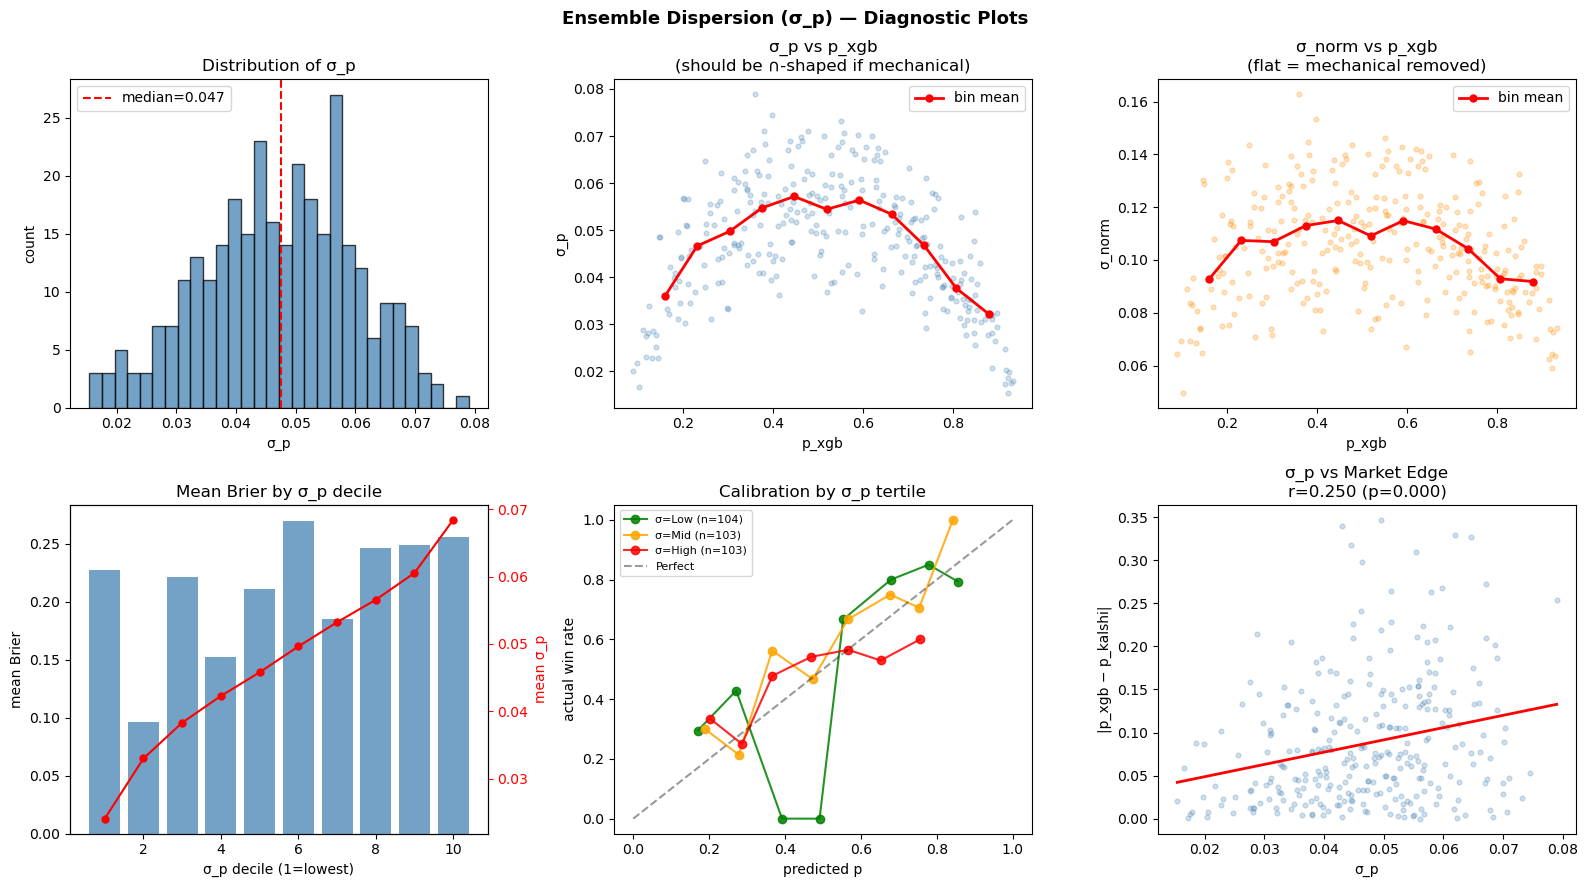

Saved: C:\Users\arius\Desktop\kalshi_wnba_bot\data\final_comparisons/sigma_analysis_plots.png


In [19]:
# ---------------------------------------------------------------------------
# Descriptive plots (6-panel)
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Ensemble Dispersion (σ_p) — Diagnostic Plots', fontsize=13, fontweight='bold')

# 1. Histogram of sigma_p
ax = axes[0, 0]
ax.hist(sigma_df['sigma_p'], bins=30, edgecolor='black', alpha=0.75, color='steelblue')
ax.axvline(sigma_df['sigma_p'].median(), color='red', linestyle='--',
           label=f'median={sigma_df["sigma_p"].median():.3f}')
ax.set_xlabel('σ_p'); ax.set_ylabel('count'); ax.set_title('Distribution of σ_p'); ax.legend()

# 2. sigma_p vs p_xgb — scatter + binned means
ax = axes[0, 1]
ax.scatter(sigma_df['p_xgb'], sigma_df['sigma_p'], alpha=0.25, s=12, color='steelblue')
pb = pd.cut(sigma_df['p_xgb'], bins=np.linspace(sigma_df['p_xgb'].quantile(0.02),
                                                  sigma_df['p_xgb'].quantile(0.98), 12))
bm = sigma_df.groupby(pb, observed=True)['sigma_p'].mean()
bm_x = [i.mid for i in bm.index]
ax.plot(bm_x, bm.values, 'r-o', linewidth=2, markersize=5, label='bin mean')
ax.set_xlabel('p_xgb'); ax.set_ylabel('σ_p')
ax.set_title('σ_p vs p_xgb\n(should be ∩-shaped if mechanical)'); ax.legend()

# 3. sigma_norm vs p_xgb — same but normalized
ax = axes[0, 2]
ax.scatter(sigma_df['p_xgb'], sigma_df['sigma_norm'], alpha=0.25, s=12, color='darkorange')
bm_n = sigma_df.groupby(pb, observed=True)['sigma_norm'].mean()
ax.plot(bm_x, bm_n.values, 'r-o', linewidth=2, markersize=5, label='bin mean')
ax.set_xlabel('p_xgb'); ax.set_ylabel('σ_norm')
ax.set_title('σ_norm vs p_xgb\n(flat = mechanical removed)'); ax.legend()

# 4. Mean Brier by sigma_p decile
ax = axes[1, 0]
dec_stats = sigma_df.groupby('sigma_dec')[['brier','sigma_p']].mean()
bars = ax.bar(dec_stats.index, dec_stats['brier'], alpha=0.75, color='steelblue')
ax2 = ax.twinx()
ax2.plot(dec_stats.index, dec_stats['sigma_p'], 'r-o', markersize=5)
ax2.set_ylabel('mean σ_p', color='red'); ax2.tick_params(axis='y', colors='red')
ax.set_xlabel('σ_p decile (1=lowest)'); ax.set_ylabel('mean Brier')
ax.set_title('Mean Brier by σ_p decile')

# 5. Calibration curves by sigma_3 bucket
ax = axes[1, 1]
colors = {'Low': 'green', 'Mid': 'orange', 'High': 'red'}
cal_bins = np.linspace(sigma_df['p_xgb'].quantile(0.02), sigma_df['p_xgb'].quantile(0.98), 9)
for bucket, col in colors.items():
    sub = sigma_df[sigma_df['sigma_3'] == bucket]
    sub2 = sub.copy(); sub2['pb'] = pd.cut(sub2['p_xgb'], bins=cal_bins)
    cal = sub2.groupby('pb', observed=True).agg(
        mp=('p_xgb','mean'), wr=(LABEL_COL,'mean'), n=(LABEL_COL,'count')
    ).dropna()
    if len(cal) > 1:
        ax.plot(cal['mp'], cal['wr'], 'o-', color=col, label=f'σ={bucket} (n={len(sub)})', alpha=0.85)
ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Perfect')
ax.set_xlabel('predicted p'); ax.set_ylabel('actual win rate')
ax.set_title('Calibration by σ_p tertile'); ax.legend(fontsize=8)

# 6. sigma_p vs |edge_kalshi|
ax = axes[1, 2]
sub_k = sigma_df.dropna(subset=['edge_kal'])
ax.scatter(sub_k['sigma_p'], sub_k['edge_kal'], alpha=0.25, s=12, color='steelblue')
r_ek, pv_ek = pearsonr(sub_k['sigma_p'], sub_k['edge_kal'])
z = np.polyfit(sub_k['sigma_p'], sub_k['edge_kal'], 1)
xr = np.linspace(sub_k['sigma_p'].min(), sub_k['sigma_p'].max(), 100)
ax.plot(xr, np.polyval(z, xr), 'r-', linewidth=2)
ax.set_xlabel('σ_p'); ax.set_ylabel('|p_xgb − p_kalshi|')
ax.set_title(f'σ_p vs Market Edge\nr={r_ek:.3f} (p={pv_ek:.3f})')

plt.tight_layout()
plt.savefig(str(OUT_DIR / 'sigma_analysis_plots.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUT_DIR}/sigma_analysis_plots.png")

In [20]:
# ---------------------------------------------------------------------------
# Decile bin analysis + conditional bins (within prob bucket, within edge bucket)
# ---------------------------------------------------------------------------

def pnl_vs_kalshi_group(g):
    g2 = g.dropna(subset=['p_kalshi'])
    if len(g2) == 0:
        return pd.Series({'n_tradeable': 0, 'pnl_net': np.nan})
    direction = np.sign(g2['p_xgb'] - g2['p_kalshi'])
    pnl = direction * (g2[LABEL_COL] - g2['p_kalshi']) - COST
    return pd.Series({'n_tradeable': len(g2), 'pnl_net': pnl.mean()})

dec_base = sigma_df.groupby('sigma_dec').apply(lambda g: pd.Series({
    'n':          len(g),
    'sigma_p':    g['sigma_p'].mean(),
    'sigma_norm': g['sigma_norm'].mean(),
    'mean_p_xgb': g['p_xgb'].mean(),
    'actual_wr':  g[LABEL_COL].mean(),
    'brier':      g['brier'].mean(),
    'logloss':    g['logloss'].mean(),
    'hit_rate':   g['correct'].mean(),
    'edge_kal':   g['edge_kal'].mean(),
    'edge_poly':  g['edge_poly'].mean(),
})).reset_index()

dec_pnl = sigma_df.groupby('sigma_dec').apply(pnl_vs_kalshi_group).reset_index()
dec_tbl = dec_base.merge(dec_pnl, on='sigma_dec')

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.width', 160)
print("SIGMA_P DECILE TABLE")
print("pnl_net = mean P&L per game when betting model direction vs Kalshi, after 3¢ cost")
print()
print(dec_tbl.to_string(index=False))

# --- A. Within probability bucket × sigma tertile ---
prob_edges  = [0.0, 0.40, 0.50, 0.60, 1.0]
prob_labels = ['<40%', '40–50%', '50–60%', '>60%']
sigma_df['prob_bin'] = pd.cut(sigma_df['p_xgb'], bins=prob_edges, labels=prob_labels)

print("\n\nA. Within prob bucket × σ_p tertile")
print("   (is dispersion informative after controlling for probability level?)")
for pb in prob_labels:
    sub = sigma_df[sigma_df['prob_bin'] == pb]
    if len(sub) < 15:
        continue
    print(f"\n  p_xgb ∈ {pb}  (n={len(sub)})")
    tbl = sub.groupby('sigma_3', observed=True).apply(lambda g: pd.Series({
        'n':        len(g),
        'mean_σ':   g['sigma_p'].mean(),
        'brier':    g['brier'].mean(),
        'logloss':  g['logloss'].mean(),
        'hit_rate': g['correct'].mean(),
        'edge_kal': g['edge_kal'].mean(),
    })).reset_index()
    print(tbl.to_string(index=False))

# --- B. Within edge bucket × sigma tertile ---
edge_edges  = [0.00, 0.03, 0.07, 0.12, 1.0]
edge_labels = ['0–3%', '3–7%', '7–12%', '12%+']
sub_kal = sigma_df.dropna(subset=['p_kalshi']).copy()
sub_kal['edge_bin'] = pd.cut(sub_kal['edge_kal'], bins=edge_edges, labels=edge_labels)

print("\n\nB. Within edge bucket × σ_p tertile  (vs Kalshi)")
print("   THE TRADING QUESTION: does low dispersion improve edge profitability?")
print("   pnl_net = mean P&L per game after 3¢ cost\n")
for eb in edge_labels:
    sub = sub_kal[sub_kal['edge_bin'] == eb]
    if len(sub) < 5:
        continue
    print(f"  |edge| ∈ {eb}  (n={len(sub)}):")
    rows = []
    for s3 in ['Low', 'Mid', 'High']:
        g = sub[sub['sigma_3'] == s3]
        if len(g) == 0:
            continue
        direction = np.sign(g['p_xgb'] - g['p_kalshi'])
        pnl_net   = (direction * (g[LABEL_COL] - g['p_kalshi']) - COST).mean()
        rows.append({'sigma': s3, 'n': len(g),
                     'mean_σ': g['sigma_p'].mean(),
                     'brier':  g['brier'].mean(),
                     'hit_rate': g['correct'].mean(),
                     'pnl_net': pnl_net})
    print(pd.DataFrame(rows).to_string(index=False))
    print()

SIGMA_P DECILE TABLE
pnl_net = mean P&L per game when betting model direction vs Kalshi, after 3¢ cost

 sigma_dec       n  sigma_p  sigma_norm  mean_p_xgb  actual_wr  brier  logloss  hit_rate  edge_kal  edge_poly  n_tradeable  pnl_net
         1 31.0000   0.0241      0.0739      0.5666     0.6129 0.2270   0.6685    0.7097    0.0502     0.0478      31.0000  -0.1523
         2 31.0000   0.0330      0.0833      0.6425     0.6452 0.0965   0.3398    0.8710    0.0688     0.0966      29.0000   0.0029
         3 31.0000   0.0383      0.0886      0.5768     0.6129 0.2215   0.6386    0.7097    0.0669     0.0941      31.0000   0.0250
         4 31.0000   0.0423      0.0946      0.5509     0.6129 0.1520   0.4819    0.8387    0.0822     0.1220      30.0000  -0.0263
         5 31.0000   0.0458      0.0998      0.4864     0.4194 0.2104   0.6078    0.6452    0.0917     0.0888      29.0000  -0.0991
         6 31.0000   0.0496      0.1074      0.4863     0.7097 0.2698   0.7456    0.4839    0.1092     0

In [21]:
# ---------------------------------------------------------------------------
# Regression tests: A (Brier), B (wrong pick), C (PnL interaction)
# ---------------------------------------------------------------------------
def ols_report(X, y, feat_names, title):
    Xc = np.column_stack([np.ones(len(X)), X])
    names = ['const'] + feat_names
    if HAS_SM:
        res = sm.OLS(y, Xc).fit()
        r2 = res.rsquared
        params, ses, pvals = res.params, res.bse, res.pvalues
    else:
        beta, _, _, _ = np.linalg.lstsq(Xc, y, rcond=None)
        ss_res = np.sum((y - Xc @ beta) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot
        params = beta
        ses = pvals = [np.nan] * len(beta)

    print(f"\n{'─'*60}")
    print(f"{title}  (n={len(y)}, R²={r2:.4f})")
    print(f"  {'feature':<22} {'coef':>10} {'se':>10} {'p':>8}  sig")
    for nm, b, se, pv in zip(names, params, ses, pvals):
        stars = '***' if pv < 0.001 else '**' if pv < 0.01 else '*' if pv < 0.05 else ''
        se_s  = f'{se:.5f}' if not np.isnan(se) else '  —  '
        pv_s  = f'{pv:.3f}'  if not np.isnan(pv) else '  —  '
        print(f"  {nm:<22} {b:>+10.5f} {se_s:>10} {pv_s:>8}  {stars}")

base = sigma_df.dropna(subset=['sigma_p'])
sp   = base['sigma_p'].values
sn   = base['sigma_norm'].values
p    = base['p_xgb'].values
p2   = p * (1 - p)   # variance capacity — key control for probability level

print('=' * 60)
print('REGRESSION TESTS')
print('f(p) control = [p_xgb, p*(1−p)] throughout')
print('=' * 60)

# Model A: Brier ~ sigma_p + f(p)
brier_y = base['brier'].values
ols_report(np.c_[sp, p, p2],   brier_y, ['sigma_p',   'p_xgb', 'p*(1-p)'],
           'Model A  : Brier ~ sigma_p + f(p)')
ols_report(np.c_[sn, p, p2],   brier_y, ['sigma_norm', 'p_xgb', 'p*(1-p)'],
           'Model A′ : Brier ~ sigma_norm + f(p)')

# Model B: wrong_pick ~ sigma_p + f(p)
wrong_y = base['wrong'].values
ols_report(np.c_[sp, p, p2],   wrong_y, ['sigma_p',   'p_xgb', 'p*(1-p)'],
           'Model B  : wrong_pick ~ sigma_p + f(p)')
ols_report(np.c_[sn, p, p2],   wrong_y, ['sigma_norm', 'p_xgb', 'p*(1-p)'],
           'Model B′ : wrong_pick ~ sigma_norm + f(p)')

# Model C: PnL_net ~ |edge| + sigma_p + |edge|*sigma_p  (vs Kalshi)
kal_b = sigma_df.dropna(subset=['p_kalshi', 'sigma_p']).copy()
direction_k  = np.sign(kal_b['p_xgb'] - kal_b['p_kalshi']).values
pnl_net_k    = direction_k * (kal_b[LABEL_COL] - kal_b['p_kalshi']).values - COST
edge_k       = kal_b['edge_kal'].values
sp_k         = kal_b['sigma_p'].values
sn_k         = kal_b['sigma_norm'].values

ols_report(np.c_[edge_k, sp_k, edge_k * sp_k], pnl_net_k,
           ['|edge|', 'sigma_p', '|edge|×sigma_p'],
           'Model C  : PnL_net ~ |edge| + sigma_p + |edge|×sigma_p  (Kalshi)')
ols_report(np.c_[edge_k, sn_k, edge_k * sn_k], pnl_net_k,
           ['|edge|', 'sigma_norm', '|edge|×sigma_norm'],
           'Model C′ : PnL_net ~ |edge| + sigma_norm + |edge|×sigma_norm  (Kalshi)')

print(f"\n{'─'*60}")
print("Interpretation guide:")
print("  Model A  β(sigma_p) > 0 → higher dispersion = worse Brier")
print("  Model B  β(sigma_p) > 0 → higher dispersion = more wrong picks")
print("  Model C  β(|edge|×sigma) < 0 → dispersion weakens edge value (key trading signal)")

REGRESSION TESTS
f(p) control = [p_xgb, p*(1−p)] throughout

────────────────────────────────────────────────────────────
Model A  : Brier ~ sigma_p + f(p)  (n=310, R²=0.0492)
  feature                      coef         se        p  sig
  const                    +0.15216        —        —    
  sigma_p                  +0.26670        —        —    
  p_xgb                    -0.11465        —        —    
  p*(1-p)                  +0.54517        —        —    

────────────────────────────────────────────────────────────
Model A′ : Brier ~ sigma_norm + f(p)  (n=310, R²=0.0492)
  feature                      coef         se        p  sig
  const                    +0.14665        —        —    
  sigma_norm               +0.12609        —        —    
  p_xgb                    -0.11483        —        —    
  p*(1-p)                  +0.57064        —        —    

────────────────────────────────────────────────────────────
Model B  : wrong_pick ~ sigma_p + f(p)  (n=310, R²=0.0470

In [22]:
# ---------------------------------------------------------------------------
# 1. Residualize σ_p on |edge|  — does σ carry info *beyond* edge?
# ---------------------------------------------------------------------------
kal_r = sigma_df.dropna(subset=['p_kalshi', 'sigma_p']).copy()
direction_r  = np.sign(kal_r['p_xgb'] - kal_r['p_kalshi']).values
kal_r['pnl_net']  = direction_r * (kal_r[LABEL_COL] - kal_r['p_kalshi']).values - COST
kal_r['edge_kal'] = (kal_r['p_xgb'] - kal_r['p_kalshi']).abs()

edge_r = kal_r['edge_kal'].values
sp_r   = kal_r['sigma_p'].values
sn_r   = kal_r['sigma_norm'].values
p_r    = kal_r['p_xgb'].values
p2_r   = p_r * (1 - p_r)

# First stage: sigma_p ~ |edge| (+ f(p) to also partial out probability level)
Xfs    = np.column_stack([np.ones(len(sp_r)), edge_r, p_r, p2_r])
b_fs,_,_,_ = np.linalg.lstsq(Xfs, sp_r, rcond=None)
kal_r['sigma_resid'] = sp_r - Xfs @ b_fs     # residual σ after removing edge & prob

Xfs_n  = np.column_stack([np.ones(len(sn_r)), edge_r, p_r, p2_r])
b_fsn,_,_,_ = np.linalg.lstsq(Xfs_n, sn_r, rcond=None)
kal_r['sigma_norm_resid'] = sn_r - Xfs_n @ b_fsn

print('=' * 65)
print('1. RESIDUALISED σ_p  (sigma after removing |edge| and f(p))')
print('   First stage: σ ~ |edge| + p_xgb + p*(1-p)')
print(f'   First-stage coefs: const={b_fs[0]:+.4f}  |edge|={b_fs[1]:+.4f}  '
      f'p={b_fs[2]:+.4f}  p²={b_fs[3]:+.4f}')
print(f'   Residual σ_resid — mean={kal_r["sigma_resid"].mean():.5f}  '
      f'std={kal_r["sigma_resid"].std():.4f}')
print()

# Second stage regressions on the residual
pnl_r_arr   = kal_r['pnl_net'].values
brier_r_arr = kal_r['brier'].values
wrong_r_arr = kal_r['wrong'].values
sr           = kal_r['sigma_resid'].values
snr          = kal_r['sigma_norm_resid'].values

for resid_col, resid_vals, lbl in [
    ('sigma_resid',      sr,  'σ_resid'),
    ('sigma_norm_resid', snr, 'σ_norm_resid'),
]:
    print(f'  Second-stage regressions on {lbl}:')
    for y_arr, y_lbl in [(pnl_r_arr, 'PnL_net'), (brier_r_arr, 'Brier'), (wrong_r_arr, 'wrong_pick')]:
        ols_report(resid_vals.reshape(-1, 1), y_arr, [resid_col], f'    {y_lbl} ~ {lbl}')
    print()

# Decile table on sigma_resid
kal_r['resid_dec'] = pd.qcut(kal_r['sigma_resid'], q=5, labels=False) + 1
resid_tbl = kal_r.groupby('resid_dec').apply(lambda g: pd.Series({
    'n':             len(g),
    'mean_σ_resid':  g['sigma_resid'].mean(),
    'mean_σ_raw':    g['sigma_p'].mean(),
    'mean_edge':     g['edge_kal'].mean(),
    'brier':         g['brier'].mean(),
    'hit_rate':      g['correct'].mean(),
    'pnl_net':       g['pnl_net'].mean(),
})).reset_index()
print('  σ_resid quintile table (quintile 1 = most under-dispersed vs edge):')
print(resid_tbl.to_string(index=False))

# ---------------------------------------------------------------------------
# 2. Within-edge-bin demeaning
# ---------------------------------------------------------------------------
print()
print('=' * 65)
print('2. WITHIN-EDGE-BIN DEMEANING')
print('   sigma_centered = sigma_p - mean(sigma_p | edge_bin)')
print('   Controls for edge-level by construction.')
print()

edge_edges  = [0.00, 0.03, 0.07, 0.12, 1.0]
edge_labels = ['0–3%', '3–7%', '7–12%', '12%+']
kal_r['edge_bin'] = pd.cut(kal_r['edge_kal'], bins=edge_edges, labels=edge_labels)
kal_r['sigma_centered']      = kal_r.groupby('edge_bin', observed=True)['sigma_p'].transform(
    lambda x: x - x.mean())
kal_r['sigma_norm_centered'] = kal_r.groupby('edge_bin', observed=True)['sigma_norm'].transform(
    lambda x: x - x.mean())

sc  = kal_r['sigma_centered'].values
snc = kal_r['sigma_norm_centered'].values

for resid_col, resid_vals, lbl in [
    ('sigma_centered',      sc,  'σ_centered'),
    ('sigma_norm_centered', snc, 'σ_norm_centered'),
]:
    print(f'  Regressions on {lbl}:')
    for y_arr, y_lbl in [(pnl_r_arr, 'PnL_net'), (brier_r_arr, 'Brier'), (wrong_r_arr, 'wrong_pick')]:
        ols_report(resid_vals.reshape(-1, 1), y_arr, [resid_col], f'    {y_lbl} ~ {lbl}')
    print()

# Within-edge-bin, split by sigma_centered tertile
print('  Conditional table: edge_bin × σ_centered tertile')
print('  (shows PnL and Brier for low/mid/high centered-sigma within each edge tier)\n')
kal_r['sc_3'] = kal_r.groupby('edge_bin', observed=True)['sigma_centered'].transform(
    lambda x: pd.qcut(x, q=3, labels=['Low','Mid','High'], duplicates='drop')
)
for eb in edge_labels:
    sub = kal_r[kal_r['edge_bin'] == eb]
    if len(sub) < 6:
        continue
    print(f'  |edge| ∈ {eb}  (n={len(sub)}):')
    rows = []
    for s3 in ['Low', 'Mid', 'High']:
        g = sub[sub['sc_3'] == s3]
        if len(g) == 0:
            continue
        rows.append({'σ_centered': s3, 'n': len(g),
                     'mean_σ':    g['sigma_p'].mean(),
                     'mean_σ_c':  g['sigma_centered'].mean(),
                     'brier':     g['brier'].mean(),
                     'hit_rate':  g['correct'].mean(),
                     'pnl_net':   g['pnl_net'].mean()})
    print(pd.DataFrame(rows).to_string(index=False))
    print()

print('Interpretation:')
print('  If PnL_net decreases Low→High in σ_centered: σ weakens edge WITHIN edge tier.')
print('  If flat: σ has no incremental info once edge level is controlled.')

1. RESIDUALISED σ_p  (sigma after removing |edge| and f(p))
   First stage: σ ~ |edge| + p_xgb + p*(1-p)
   First-stage coefs: const=+0.0097  |edge|=+0.0100  p=-0.0009  p²=+0.1877
   Residual σ_resid — mean=-0.00000  std=0.0084

  Second-stage regressions on σ_resid:

────────────────────────────────────────────────────────────
    PnL_net ~ σ_resid  (n=296, R²=0.0073)
  feature                      coef         se        p  sig
  const                    +0.00096        —        —    
  sigma_resid              +4.67885        —        —    

────────────────────────────────────────────────────────────
    Brier ~ σ_resid  (n=296, R²=0.0000)
  feature                      coef         se        p  sig
  const                    +0.21113        —        —    
  sigma_resid              -0.03862        —        —    

────────────────────────────────────────────────────────────
    wrong_pick ~ σ_resid  (n=296, R²=0.0006)
  feature                      coef         se        p  sig
  co